<a href="https://colab.research.google.com/github/Ida-bit97/Parental_leave_denmark/blob/main/Parental_leave_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Parental Leave Gender Gap in Denmark 2015 - 2024**


**Data Analysis | Python · SQL · Tableau**

This project explores the gender gap in parental leave across Danish
municipalities using data from Statistics Denmark (Danmarks Statistik).

**Research question:** How has the gender gap in parental leave evolved
in Denmark between 2015 and 2024, and what role do education level
and region play?

## **1. Data Collection**

Data is fetched directly from the Statistics Denmark API (api.statbank.dk).
This approach has no row limit unlike manual CSV downloads, and ensures
the analysis is fully reproducible.

The BARSEL05 table contains parental leave statistics. We request a
focused subset of the available variables rather than the full dataset
(which would exceed the API's 1,000,000 cell limit):

**Metrics (TAL):**
- Mother's average leave days after birth (220)
- Father's average leave days after birth (330)
→ These two metrics allow direct gender comparison on equal terms

**Entitlement filter (BERET):**
- Both mother and father entitled to parental benefits (511)
→ This is the fairest comparison group — both parents had the legal
right to take leave, so any gap reflects choice rather than constraint

**Education levels (MORUD, FARUD):**
- All levels included
→ Allows us to explore whether education explains part of the gender gap

**Region (OMRÅDE):**
- All 98 municipalities + aggregates
→ Enables geographic analysis of regional differences

**Years (Tid):** 2015–2023
→ Covers the period before and after the 2022 parental leave law reform,
allowing us to measure its impact

In [1]:
import requests
import pandas as pd

In [2]:
# Fetching the full metadata for the BARSEL05 table
response = requests.get("https://api.statbank.dk/v1/tableinfo/BARSEL05?lang=en")
metadata = response.json()

# Printing each variable with its code and all possible values for a concious choice
for variable in metadata["variables"]:
    print(f"\nCode: {variable['id']}")
    print(f"Label: {variable['text']}")
    print("Values:")
    for val in variable["values"]:
        print(f"  {val['id']} = {val['text']}")


Code: TAL
Label: unit
Values:
  000 = Number of couples
  110 = Child - Number of days with at least one parent on benefits
  120 = Child - Number of days between parents' first and last day on benefits
  200 = Mother - total days on parental leave (benefits) on average
  202 = Mother - days on parental leave (benefits) before birth on average
  220 = Mother - days on parental leave (benefits) after birth on average
  330 = Father - days on parental leave (benefits) after birth on average
  400 = Mother -total days of salary during parental leave on average
  404 = Mother -days of salary during parental leave before birth on average
  440 = Mother -days of salary during parental leave after birth on average
  550 = Father - days of salary during parental leave after birth on average
  600 = Mother - total days without salary during parental leave on average
  606 = Mother -days without salary during parental leave before birth on average
  660 = Mother -days without salary during pare

In [3]:
#Conducting selective parsing
url = "https://api.statbank.dk/v1/data"

params = {
    "table": "BARSEL05",
    "format": "CSV",
    "lang": "en",
    "delimiter": "Semicolon",
    "variables": [
        #parameters chosen here and afterwards are commented:
        # - 330 = Father's average leave days after birth
        # - 220 = Mother's average leave days after birth
        {"code": "TAL",    "values": ["330", "220"]},

        # 511 = Both mother and father entitled to parental benefits
        # This is the fairest comparison group — both parents had the right
        # to take leave, so any gap we see is a choice, not a constraint
        {"code": "BERET",  "values": ["511"]},

        # All education levels for both parents
        {"code": "MORUD",  "values": ["*"]},
        {"code": "FARUD",  "values": ["*"]},

        # All regions
        {"code": "OMRÅDE", "values": ["*"]},

        # All years 2015-2023
        {"code": "Tid",    "values": ["*"]}
    ]
}

response = requests.post(url, json=params)
response.encoding = "utf-8"

# Check it worked
print("Status code:", response.status_code)
print("Preview:", response.text[:300])

Status code: 200
Preview: ﻿TAL;BERET;MORUD;FARUD;OMRÅDE;TID;INDHOLD
Father - days on parental leave (benefits) after birth on average;Both mother and father are entitled to parental leave;All mothers, regardless of education;All fathers, regardless of education;All Denmark;2015;29.8
Father - days on parental leave (benefit


In [4]:
#Preparing data for the analysis
with open("barsel_api.csv", "w", encoding="utf-8") as f:
    f.write(response.text)

df = pd.read_csv("barsel_api.csv", sep=";", encoding="utf-8-sig")

#Renaming columns to make them more understandable
df.columns = ["metric", "entitlement", "mothers_edu", "fathers_edu", "region", "year", "value"]

#Checking what was done
print(df.shape)
print(df.head(10))
print(f"\nUnique regions: {df['region'].nunique()}")
print(f"\nUnique metrics: {df['metric'].unique()}")
print(f"\nMissing values: {df['value'].isna().sum()}")

(79920, 7)
                                              metric  \
0  Father - days on parental leave (benefits) aft...   
1  Father - days on parental leave (benefits) aft...   
2  Father - days on parental leave (benefits) aft...   
3  Father - days on parental leave (benefits) aft...   
4  Father - days on parental leave (benefits) aft...   
5  Father - days on parental leave (benefits) aft...   
6  Father - days on parental leave (benefits) aft...   
7  Father - days on parental leave (benefits) aft...   
8  Father - days on parental leave (benefits) aft...   
9  Father - days on parental leave (benefits) aft...   

                                         entitlement  \
0  Both mother and father are entitled to parenta...   
1  Both mother and father are entitled to parenta...   
2  Both mother and father are entitled to parenta...   
3  Both mother and father are entitled to parenta...   
4  Both mother and father are entitled to parenta...   
5  Both mother and father are entitl

## **2. Loading into SQLite & SQL Analysis**

The cleaned dataframe is loaded into a local SQLite database.
This allows us to query the data using SQL.

Three questions were explored:
1. How has the gender gap changed year by year?
2. Does father's education level affect how much leave he takes?
3. Which municipalities have the smallest gender gap in 2024?

In [5]:
import sqlite3

#Creating the database and connecting to it
conn = sqlite3.connect("parental_leave.db")

#Saving the dataframe as a SQL table
df.to_sql("parental_leave", conn, if_exists="replace", index=False)

#Verifying it loaded correctly
result = pd.read_sql_query("SELECT COUNT(*) as total_rows FROM parental_leave", conn)
print(result)

preview = pd.read_sql_query("""
    SELECT *
    FROM parental_leave
    LIMIT 5
""", conn)
print(preview)

   total_rows
0       79920
                                              metric  \
0  Father - days on parental leave (benefits) aft...   
1  Father - days on parental leave (benefits) aft...   
2  Father - days on parental leave (benefits) aft...   
3  Father - days on parental leave (benefits) aft...   
4  Father - days on parental leave (benefits) aft...   

                                         entitlement  \
0  Both mother and father are entitled to parenta...   
1  Both mother and father are entitled to parenta...   
2  Both mother and father are entitled to parenta...   
3  Both mother and father are entitled to parenta...   
4  Both mother and father are entitled to parenta...   

                            mothers_edu                           fathers_edu  \
0  All mothers, regardless of education  All fathers, regardless of education   
1  All mothers, regardless of education  All fathers, regardless of education   
2  All mothers, regardless of education  All fathers, r

In [6]:
#Checking whether we have both mothers' and fathers' parental leave dates for each year
pd.read_sql_query("""
    SELECT DISTINCT metric, year
    FROM parental_leave
    ORDER BY year
""", conn)

,metric,year
0,Father - days on parental leave (benefits) aft...,2015
1,Mother - days on parental leave (benefits) aft...,2015
2,Father - days on parental leave (benefits) aft...,2016
3,Mother - days on parental leave (benefits) aft...,2016
4,Father - days on parental leave (benefits) aft...,2017
5,Mother - days on parental leave (benefits) aft...,2017
6,Father - days on parental leave (benefits) aft...,2018
7,Mother - days on parental leave (benefits) aft...,2018
8,Father - days on parental leave (benefits) aft...,2019
9,Mother - days on parental leave (benefits) aft...,2019


### **2.1. How has the gender gap changed year by year?**

In [9]:
#Сalculation of the average number of leave days for mothers and fathers separately
#for Tableau
avg_days_mom_dad = pd.read_sql_query("""
    SELECT
        year,
        metric,
        ROUND(AVG(value)) AS avg_days
    FROM parental_leave
    WHERE region = 'All Denmark'
      AND mothers_edu = 'All mothers, regardless of education'
      AND fathers_edu = 'All fathers, regardless of education'
    GROUP BY year, metric
    ORDER BY year, metric
""", conn)

avg_days_mom_dad

,year,metric,avg_days
0,2015,Father - days on parental leave (benefits) aft...,30.0
1,2015,Mother - days on parental leave (benefits) aft...,283.0
2,2016,Father - days on parental leave (benefits) aft...,31.0
3,2016,Mother - days on parental leave (benefits) aft...,282.0
4,2017,Father - days on parental leave (benefits) aft...,33.0
5,2017,Mother - days on parental leave (benefits) aft...,281.0
6,2018,Father - days on parental leave (benefits) aft...,34.0
7,2018,Mother - days on parental leave (benefits) aft...,282.0
8,2019,Father - days on parental leave (benefits) aft...,36.0
9,2019,Mother - days on parental leave (benefits) aft...,280.0


In [8]:
#Transforming information to be more readable and demonstrative to read in Colab
df_gap_time = pd.read_sql_query("""
    SELECT
        year,
        ROUND(MAX(CASE WHEN metric LIKE 'Mother%' THEN avg_days END), 0) AS mother_days,
        ROUND(MAX(CASE WHEN metric LIKE 'Father%' THEN avg_days END), 0) AS father_days,
        ROUND(MAX(CASE WHEN metric LIKE 'Mother%' THEN avg_days END) -
              MAX(CASE WHEN metric LIKE 'Father%' THEN avg_days END), 0) AS gap_days
    FROM (
        SELECT
            year,
            metric,
            AVG(value) AS avg_days
        FROM parental_leave
        WHERE region = 'All Denmark'
          AND mothers_edu = 'All mothers, regardless of education'
          AND fathers_edu = 'All fathers, regardless of education'
        GROUP BY year, metric
    )
    GROUP BY year
    ORDER BY year
""", conn)

df_gap_time

,year,mother_days,father_days,gap_days
0,2015,283.0,30.0,253.0
1,2016,282.0,31.0,251.0
2,2017,281.0,33.0,249.0
3,2018,282.0,34.0,248.0
4,2019,280.0,36.0,245.0
5,2020,280.0,37.0,243.0
6,2021,278.0,39.0,239.0
7,2022,263.0,53.0,211.0
8,2023,242.0,72.0,170.0
9,2024,240.0,77.0,163.0


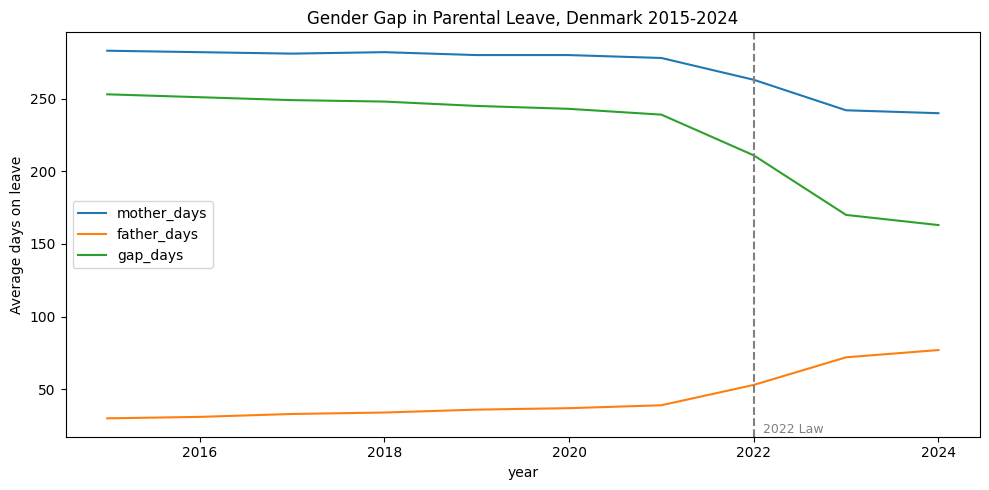

In [35]:
import matplotlib.pyplot as plt

# Simple line chart of gender gap over time
df_gap_time.plot(
    x='year',
    y=['mother_days', 'father_days', 'gap_days'],
    title='Gender Gap in Parental Leave, Denmark 2015-2024',
    figsize=(10, 5)
)
plt.ylabel('Average days on leave')
plt.axvline(x=2022, color='grey', linestyle='--')
plt.text(2022.1, 20, '2022 Law', color='grey', fontsize=9)
plt.legend(loc='center left')
plt.tight_layout()
plt.show()

**Key findings about gender gap dynamics:**
- The gap is closing fast — from 253 days in 2015 down to 163 days in 2024. That's a reduction of 90 days over 10 years.

- 2022 was a turning point — the drop in gap_days accelerates sharply
after 2021, coinciding with Denmark's new parental leave law which
gave fathers more earmarked weeks.

- Fathers more than doubled their leave in 10 years — from 30 days in 2015 to 77 in 2024. Meanwhile mothers went slightly down from 283 to 240. So the gap is narrowing from both sides.

### **2.2. Does father's education level affect how much leave he takes?**

In [11]:
#Getting Tableau-ready version (long) of how fathers with different level of education differ
df_education = pd.read_sql_query("""
    SELECT
        year,
        fathers_edu,
        ROUND(AVG(value)) AS avg_days
    FROM parental_leave
    WHERE region = 'All Denmark'
      AND fathers_edu != 'All fathers, regardless of education'
      AND metric LIKE 'Father%'
    GROUP BY year, fathers_edu
    ORDER BY year,fathers_edu
""", conn)
df_education

,year,fathers_edu,avg_days
0,2015,Father bachelor,34.0
1,2015,Father lower secondary,21.0
2,2015,Father master,38.0
3,2015,Father short cycle tertiary,33.0
4,2015,Father upper secondary,23.0
5,2016,Father bachelor,34.0
6,2016,Father lower secondary,20.0
7,2016,Father master,39.0
8,2016,Father short cycle tertiary,32.0
9,2016,Father upper secondary,23.0


In [25]:
#Presenting in a structured format
df_education_wide = df_education.pivot(
    index='year',
    columns='fathers_edu',
    values='avg_days'
).reset_index()

df_education_wide.columns = df_education_wide.columns.str.replace('Father ', '')

df_education_wide

fathers_edu,year,bachelor,lower secondary,master,short cycle tertiary,upper secondary
0,2015,34.0,21.0,38.0,33.0,23.0
1,2016,34.0,20.0,39.0,32.0,23.0
2,2017,34.0,22.0,41.0,33.0,24.0
3,2018,36.0,22.0,43.0,34.0,25.0
4,2019,37.0,23.0,44.0,32.0,26.0
5,2020,37.0,22.0,47.0,33.0,27.0
6,2021,40.0,23.0,49.0,36.0,29.0
7,2022,53.0,37.0,62.0,48.0,42.0
8,2023,73.0,57.0,81.0,69.0,63.0
9,2024,77.0,60.0,83.0,72.0,67.0


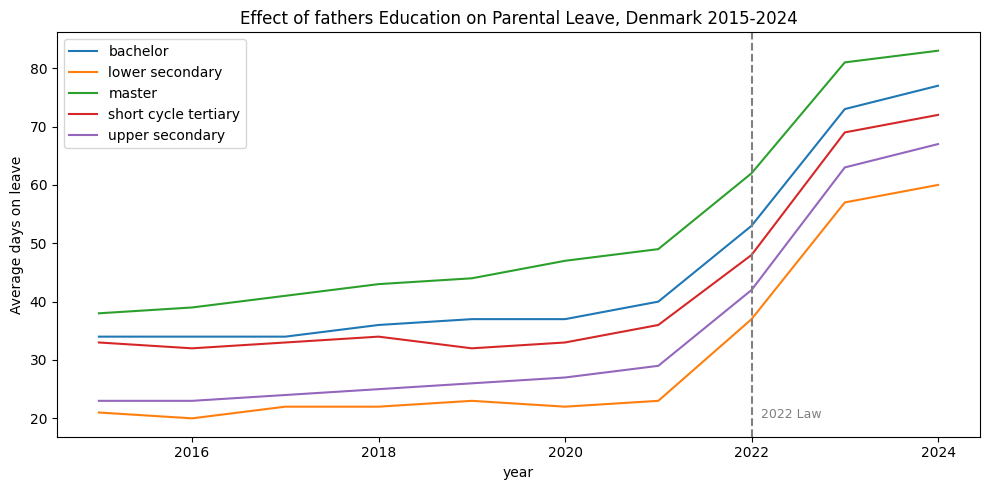

In [32]:
#Chat for educational effect on fathers leave
cols_ = df_education_wide.columns

df_education_wide.plot(
    x='year',
    y= cols_[1:],
    title='Effect of fathers Education on Parental Leave, Denmark 2015-2024',
    figsize=(10, 5)
)
plt.ylabel('Average days on leave')
plt.axvline(x=2022, color='grey', linestyle='--')
plt.text(2022.1, 20, '2022 Law', color='grey', fontsize=9)
plt.legend()
plt.tight_layout()
plt.show()

**Key findings about educational effect on fathers leave:**

*   The higher the father's level of education, the longer he takes paternity leave - this trend has been maintained for 10 years.
*   All education groups showed a sharp increase after the 2022 law —
  fathers more than doubled their leave days between 2021 and 2023
  regardless of education level.
* However, the growth is visibly slowing in 2024, with lines becoming
  flatter across all groups. This may suggest the law created a rapid
  one-time boost rather than a sustained long-term trend — worth
  monitoring in future years.



### **2.3. Which municipalities have the smallest gender gap in 2024?**

In [60]:
#All years averaged
df_regions_all_years = pd.read_sql_query("""
      SELECT
        region,
        ROUND(MAX(CASE WHEN metric LIKE 'Mother%' THEN avg_days END), 0) AS mother_days,
        ROUND(MAX(CASE WHEN metric LIKE 'Father%' THEN avg_days END), 0) AS father_days,
        ROUND(MAX(CASE WHEN metric LIKE 'Mother%' THEN avg_days END) -
              MAX(CASE WHEN metric LIKE 'Father%' THEN avg_days END), 0) AS gap_days
      FROM (SELECT
                          region,
                          metric,
                          AVG(value) AS avg_days
            FROM parental_leave
            WHERE mothers_edu = 'All mothers, regardless of education'
            AND fathers_edu = 'All fathers, regardless of education'
            AND region != 'Not stated'
            GROUP BY region, metric)
      GROUP BY region
      ORDER BY gap_days ASC

""", conn)
df_regions_all_years.head(5)

,region,mother_days,father_days,gap_days
0,Frederiksberg,257.0,59.0,198.0
1,Copenhagen,260.0,58.0,201.0
2,Province Byen København,260.0,58.0,202.0
3,Lyngby-Taarbæk,262.0,55.0,207.0
4,Rudersdal,260.0,52.0,208.0


I should write in README "Rows with unidentified region were excluded from regional analysis" (because I got a Not stated region)

In [61]:
#data for 2024 only
df_regions_2024 = pd.read_sql_query("""
      SELECT
        region,
        ROUND(MAX(CASE WHEN metric LIKE 'Mother%' THEN avg_days END), 0) AS mother_days,
        ROUND(MAX(CASE WHEN metric LIKE 'Father%' THEN avg_days END), 0) AS father_days,
        ROUND(MAX(CASE WHEN metric LIKE 'Mother%' THEN avg_days END) -
              MAX(CASE WHEN metric LIKE 'Father%' THEN avg_days END), 0) AS gap_days
      FROM (SELECT
                          region,
                          metric,
                          AVG(value) AS avg_days
            FROM parental_leave
            WHERE mothers_edu = 'All mothers, regardless of education'
            AND fathers_edu = 'All fathers, regardless of education'
            AND region != 'Not stated'
            AND year = 2024
            GROUP BY region, metric)
      GROUP BY region
      ORDER BY gap_days ASC

""", conn)
df_regions_2024.head(5)

,region,mother_days,father_days,gap_days
0,Lyngby-Taarbæk,225.0,90.0,135.0
1,Frederiksberg,228.0,89.0,138.0
2,Copenhagen,229.0,89.0,140.0
3,Province Byen København,229.0,89.0,140.0
4,Rudersdal,226.0,85.0,141.0


**Key finding about regional aspect of gender gap:**

The top 5 municipalities include the capital and its immediate surroundings, both when assessing the 10-year average and when considering data only for 2024.

Due to the large number of municipalities
(98) and the relatively small spread between values, a static chart
would not be informative here.

🗺️ **See the interactive map in the Tableau dashboard:**  
[Parental Leave Gender Gap in Denmark](https://public.tableau.com/app/profile/daria.ivchenko/viz/BarselDashboard/ParentalLeaveGenderGapinDenmark)

##**3. Data preparation for Tableau dashboard**

In [64]:
#Export databases to CSV
avg_days_mom_dad.to_csv("tableau_gap_avg_days_mom_dad.csv", index=False, encoding="utf-8")
df_gap_time.to_csv("tableau_gap_over_time.csv", index=False, encoding="utf-8")
df_education.to_csv("tableau_education_effect.csv", index=False, encoding="utf-8")
df_regions_all_years.to_csv("tableau_regional_all_years.csv", index=False, encoding="utf-8")
df_regions_2024.to_csv("tableau_regional_2024.csv", index=False, encoding="utf-8")

print("✅ Exported successfully!")
print(f"Comparison of mothers and dads:      {avg_days_mom_dad.shape}")
print(f"Gap over time:      {df_gap_time.shape}")
print(f"Education effect:   {df_education.shape}")
print(f"Regional (all years):    {df_regions_all_years.shape}")
print(f"Regional (2024):    {df_regions_2024.shape}")

✅ Exported successfully!
Comparison of mothers and dads:      (20, 3)
Gap over time:      (10, 4)
Education effect:   (50, 3)
Regional (all years):    (110, 4)
Regional (2024):    (110, 6)


In [65]:
#adding coordinates manually for Tableau interactive map
from geopy.geocoders import Nominatim
import time

geolocator = Nominatim(user_agent="barsel_project")

def get_coords(municipality):
    try:
        location = geolocator.geocode(f"{municipality}, Denmark")
        time.sleep(1)  # be polite to the API
        if location:
            return location.latitude, location.longitude
        return None, None
    except:
        return None, None

df_regions_2024["latitude"] = None
df_regions_2024["longitude"] = None

for idx, row in df_regions_2024.iterrows():
    lat, lon = get_coords(row["region"])
    df_regions_2024.at[idx, "latitude"] = lat
    df_regions_2024.at[idx, "longitude"] = lon
    print(f"✅ {row['region']}: {lat}, {lon}")

df_regions_2024.to_csv("tableau_regional_2024_coords.csv", index=False, encoding="utf-8")
print("Done!")

✅ Lyngby-Taarbæk: 55.7854145, 12.5202151
✅ Frederiksberg: 55.678016, 12.5326186
✅ Copenhagen: 55.6867243, 12.5700724
✅ Province Byen København: None, None
✅ Rudersdal: 55.8190974, 12.4656899
✅ Furesø: 55.801089, 12.4089396
✅ Allerød: 55.8707776, 12.3556762
✅ Gentofte: 55.7535946, 12.541436
✅ Aarhus: 56.1496278, 10.2134046
✅ Billund: 55.7247018, 9.1195835
✅ Gladsaxe: 55.7383794, 12.4696107
✅ Egedal: 55.7797855, 12.1854997
✅ Rødovre: 55.6812495, 12.4547294
✅ Skanderborg: 56.0351868, 9.9317878
✅ Sorø: 55.4365822, 11.5629363
✅ Ærø: 54.8940165, 10.3239031
✅ Ballerup: 55.7303589, 12.3612313
✅ Dragør: 55.592487, 12.6719953
✅ Province Nordsjælland: None, None
✅ Roskilde: 55.6433478, 12.0819247
✅ Hillerød: 55.9285735, 12.3063909
✅ Odense: 55.3997225, 10.3852104
✅ Hørsholm: 55.8832986, 12.5000112
✅ Province Københavns omegn: None, None
✅ All Denmark: None, None
✅ Province Østjylland: None, None
✅ Syddjurs: 56.271469, 10.6629495
✅ Favrskov: 56.3364329, 9.9909073
✅ Fredensborg: 55.9821565, 12.3950

In [ ]:
#looking at missing data - all the missing data concerns agglomerations, so everithing is alright
null_regions = []
for index, row in df_regions_2024.iterrows():
  lat = row['latitude']
  if pd.isna(lat) == True:
    print(f'{row["region"]}')

Province Byen København
Province Nordsjælland
All Denmark
Province Københavns omegn
Province Østjylland
Province Fyn
Province Østsjælland
Province Sydjylland
Province Nordjylland
Province Bornholm
Province Vestjylland
Province Vest- og Sydsjælland


##**Conclusion**

This analysis reveals that Denmark has made meaningful progress in
closing the parental leave gender gap over the past decade — driven
significantly by the 2022 law reform. However, the slowing growth
in 2024 suggests the law may have delivered a one-time boost rather
than a sustained shift in behaviour.

The persistent correlation between education level and paternity leave
length, alongside the geographic concentration of gender equality in
the Copenhagen area, suggests that cultural and socioeconomic factors
play an important role beyond legislation alone.

Further analysis with 2025+ data will be needed to determine whether
the post-2022 plateau is a temporary adjustment or a sign that
additional policy measures are needed.